### Pivot Table

The pivot table takes simple column-wise data as input, and groups the entries into a two-dimensional table that provides a multidimensional summarization of the data.

- Simple Input ➡️ Smart Output: Yeh aam column wale data ko leta hai aur use ek aisi summary report mein badal deta hai jise dekhkar aap ek baar mein bade faisle le sakein.

- Grouping (Group banana): Yeh duplicate entries ko ek sath jodta hai. Jaise agar aapke data mein delhi 50 baar aaya hai, toh pivot table use ek hi row mein group kar dega.

- Multidimensional Summarization (Har taraf se summary): Aap ek sath kai cheezein dekh sakte hain. Jaise—Row mein branch (cse, ece), Column mein shahar (delhi, mumbai), aur beech mein unka Average Package ya Total Students.

In [3]:
import numpy  as np
import pandas as pd
import seaborn as sns 

df=sns.load_dataset("tips")  #tips is  an inbuilt seaborn dataset  regarding customer details visiting a restaurant 

#Pivot table is generally used on categoorical columns 
df 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
#Mujhe ye nikalna hai gender ke basis pe avg total bill 
# males kitna avg bill and females kitna avg bill pay karti hai ?

#first way 
df.groupby("sex")["total_bill"].mean()

sex
Male      20.744076
Female    18.056897
Name: total_bill, dtype: float64

In [5]:
#Ab yeh to janna hi hai  par yeh bhi janna hai ki smokers male and female kitna avg bill pay karte hai and on smokers kitna  karte hai 

#Ab 2 columns ke basis pe group karna padega 

bills=df.groupby(["sex","smoker"])["total_bill"].mean()
bills #Multiindex dataframe 

bills.unstack()


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [6]:
#Yhi cheez easily pivot table se bann jaati

df.pivot_table(index="sex",columns="smoker",values="total_bill") 
#Default behaviour ye hai ki values par mean leta hai (multidimensional summarization)

#Gives you a lot of flexibility  

#Isme aggregate parameter hota hai jiski default value mean hoti hai par chaho to set kar skte ho phir data pe wohi function lagayega ye 


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [7]:
df.pivot_table(index="sex",columns="smoker",values="total_bill",aggfunc="sum") 

smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [8]:
# What if values parameter main value specify na karu
df.dtypes
df.pivot_table(index="sex",columns="smoker",values=["total_bill","tip","size"])

#agar values nhi doge to default mean har bahe column pe lagega par mean sirf numeric columns ka nikal skta hai  and date and time category dtype ke hai toh unpe nhi lagega and error aayega pandas  ke pehle versions main automatic ignore kar deta  thha par ab nhi karega hence values specify karni hongi 

size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [9]:
#Multidimensional analysis 
df.pivot_table(index=["sex","smoker"],columns=["day","time"],values="total_bill")
#5D pivot table 

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [10]:
df.pivot_table(index=["sex","smoker"],columns=["day","time"])

size                                                   tip  \
day                Thur              Fri              Sat       Sun      Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner     Lunch   
sex    smoker                                                                   
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  3.058000   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  2.941500   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  2.990000   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  2.437083   

                                                      total_bill         \
day                    Fri              Sat       Sun       Thur          
time          Dinner Lunch Dinner    Dinner    Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes       NaN  1.90  3.246  2.879259  3.521333  19.171000    NaN   
       No        NaN   NaN  2.500  3.256563  3.115349  18.486500    NaN   
Female Yes       NaN  2.66  2.700  2.868667  3.500000  19.218571    NaN   
       No        3.0  3.00  3.250  2.724615  3.329286  15.899167  18.78   

                                                        
day                  Fri                Sat        Sun  
time               Lunch  Dinner     Dinner     Dinner  
sex    smoker                                           
Male   Yes     11.386667  25.892  21.837778  26.141333  
       No            NaN  17.475  19.929063  20.403256  
Female Yes     13.260000  12.200  20.266667  16.540000  
       No      15.980000  22.750  19.003846  20.824286

In [11]:
df.pivot_table(index=["sex","smoker"],columns=["day","time"],aggfunc={"size":"mean","tip":"max","total_bill":"sum"})

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71    NaN  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73    NaN    NaN   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53    NaN  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                       
day                       Sat     Sun  
time           Dinner  Dinner  Dinner  
sex    smoker                          
Male   Yes     129.46  589.62  392.12  
       No       34.95  637.73  877.34  
Female Yes      48.80  304.00   66.16  
       No       22.75  247.05  291.54

In [12]:
#margins 
df.pivot_table(index="sex",columns="smoker",values="total_bill",aggfunc="sum") 

#Ab isme total calculate kar skte ho using a parameter margins 

df.pivot_table(index="sex",columns="smoker",values="total_bill",aggfunc="sum",margins=True) 
# basically jo bhi hum aggfunc lagate hai columns pe to un saare columns ka result leke sum kar deta  hai or har row ka sum all naam ke column main daalke wo  column add kar deta hai 



smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [13]:
#Plotting tables using datasets /pivot_tables 

df = pd.read_csv(r"C:\Users\Asus\Downloads\expense_data.csv")
#daily kharcho ka dataset 
df.head(5)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [14]:
#Plot month by month uska expense kitna horaha hai 
df["Date"]=pd.to_datetime(df["Date"])
df["Date"].dt.month_name()
#Since date was a categorry dtype therefore moth extract nhi kar paarahe the to to_datetime se convert kar liya ek format main 
df["month"]=df["Date"].dt.month_name()

In [15]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,6440.72,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


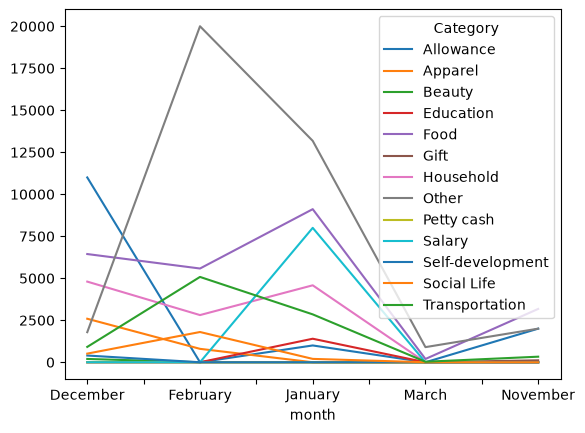

In [16]:
sum=df.pivot_table(index="month",columns="Category",values="INR",aggfunc="sum",fill_value=0) #Nan values ko zero se replace kar dega 
sum.plot()
sum

In [17]:
import pandas as pd
import numpy as np 
#Vectorized string operations:-

#WHat are vectorized operations ?
#Vectors par operations ya Ek operation jo poore array/collection pe ek saath, single call me apply ho jaye — bina explicit loop likhe
a=np.array([1,2,3,4])
a*4
#Operations chalya a par par a ke saare elements 4 se multiply hogye 

array([ 4,  8, 12, 16])

In [18]:
#problem in vectorized operations in vanilla python

#  python main ye tpic alag se isliye hai kyunki traditional oython code main vecotrizations operations dhag se kaam nhi karte 

#Example
s=["cat","mat",None,"rat"]
s.startswith("c")# ab ye vectorized operation karne ki koshish karunga to expected to yeh hoga ki har element compare hoke answer ki list mil jaye par error aajayega ki list ke pass startswith attribute nhi hai karke 

# [i.startswith("c") for i in s ] #None type  object ke pass startswith ka koi attribute nhi hai (sbse badi problem of traditional python kyunki aise dikkat aasakti hai )

#Upar se kaafi slow hai 


AttributeError: 'list' object has no attribute 'startswith'

In [ ]:
#how  pandas solve this issue ?
s=pd.Series(["cat","mat",None,"rat"])
#str is string accessor yni pandas ke series aya dataframes main jo string use hoti hai column main uspar string operations lagane ke liye access karna necessary hai 
s.str.startswith("c") #None ko bhi handle kar lega 


In [19]:
df1=pd.read_csv(r"C:\Users\Asus\Downloads\titanic.csv")
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
#since abhi mujhe string operations ke baare main learn karna hai therefoe i will select ka string column

df1["Name"].str.lower()
df1["Name"].str.capitalize()
df1["Name"].str.title()


0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [21]:
df1["Name"].str.len() #sabhi strings ki length dedega 
df1["Name"].str.len().max() #Sabse zyada length wala naam ki lengthh dedega

#Ab agar ye sabse lamba naam chahiye 
mask=df1["Name"].str.len()==df1["Name"].str.len().max() #gives you a boolean series to be used as aa boolean mask 
df1["Name"][mask]
#sirf naam chahiye to .values[0] karlo 

307    Penasco y Castellana, Mrs. Victor de Satode (M...
Name: Name, dtype: str

In [22]:
#strip leading and  trailing spaces hata dega
df1["Name"].str.strip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [35]:
#name wale column ke 3 components hai naam ke surname,title,name 
#dataset main 3 column banane hai title name and surname

#Ab surname and (title,name) is sepperated by a , to , pe split kardo 
self=df1["Name"].str.split(",") #isse mujhe alag alag lists mil  jayengi jisme surname,name and title ki various lists hogi ab sirf surname chahiye to get function lagana hoga par string accessor ke bina nhi laga paoge since vectorized operations

df1["lastname"]=self.str.get(0) #saare list ke pehle index ka material mil jayega series main .
#Sare surname ki series mil gayi 
title_n_name=self.str.get(1).str.split(".") #isse mujhe  ek aisi seriesmili jisme list hai title,name ke form ki

df1["firstname"]=title_n_name.str.get(1).str.strip()
df1["title"]=title_n_name.str.get(0).str.strip()

# ab main firstname,title,surnameka ek dataframe bana dunga 
new_df=pd.DataFrame(df1[["firstname","title","lastname"]])
new_df

,firstname,title,lastname
0,Owen Harris,Mr,Braund
1,John Bradley (Florence Briggs Thayer),Mrs,Cumings
2,Laina,Miss,Heikkinen
3,Jacques Heath (Lily May Peel),Mrs,Futrelle
4,William Henry,Mr,Allen
...,...,...,...
886,Juozas,Rev,Montvila
887,Margaret Edith,Miss,Graham
888,"Catherine Helen ""Carrie""",Miss,Johnston
889,Karl Howell,Mr,Behr


In [24]:
# another way is sir ka tareeka 
df1["Name"].str.split(",").str.get(1).str.strip().str.split(" ",n=1,expand=True) #Ab str.strip() se pehle leading and trailing spaces haataye and n=1 se kitne piece main split karna hai  and expand=True se dtaframe main chala jayega  ab df1[["title","firstname"] main daal lena ho jayega 

,0,1
0,Mr.,Owen Harris
1,Mrs.,John Bradley (Florence Briggs Thayer)
2,Miss.,Laina
3,Mrs.,Jacques Heath (Lily May Peel)
4,Mr.,William Henry
...,...,...
886,Rev.,Juozas
887,Miss.,Margaret Edith
888,Miss.,"Catherine Helen ""Carrie"""
889,Mr.,Karl Howell


In [25]:
#Ab Mrs Miss and Ms same to nhi hota par females ke liye  hi use hota hai Mlle bhi french version hai  to in sabke sirf Mrs se replace karna hai 

df1["title"].str.replace("Ms","Mrs") #isse Ms replace hogaya Mrs se 
df1["title"].str.replace("Mlle","Mrs")

df1["title"]=df1["title"].str.replace("Ms|Mlle","Miss",regex=True)
#Ek saath multiple replacement karne ke liye regex lagana padega jo baad main padhege 

In [37]:
#Filtering 
#Startswith/endswith
df1.loc[842]
df1[df1["firstname"].str.startswith("A")]
# repr(df1["firstname"].loc[842]) string ke characteristic batayega
# df1["firstname"] 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,firstname,title
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S,Andersson,Anders Johan,Mr
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q,McGowan,"Anna ""Annie""",Miss
35,36,0,1,"Holverson, Mr. Alexander Oskar",male,42.0,1,0,113789,52.0000,NaN,S,Holverson,Alexander Oskar,Mr
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S,Vander Planke,Augusta Maria,Miss
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN,Icard,Amelie,Miss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C,Serepeca,Augusta,Miss
845,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S,Abbing,Anthony,Mr
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.0,1,0,SC/PARIS 2149,13.8583,NaN,C,Duran y More,Asuncion,Miss
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,Najib,"Adele Kiamie ""Jane""",Miss


In [40]:
#isdigit se digit hai ki nhi ye check kar skte sakte ho 

# advance filtering through regex 
# search John in any case upper lower howerver you want 
df1[df1["firstname"].str.contains("john",case=True)]

#Surname vowel se shuru and khatam hota hai wo names chahiye 
df1[df1["firstname"].str.contains("^[aeiouAEIOU].+[aeiouAEIOU]$")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,firstname,title
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q,Rice,Eugene,Master
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.00,2,0,345764,18.0000,NaN,S,Vander Planke,Augusta Maria,Miss
61,62,1,1,"Icard, Miss. Amelie",female,38.00,0,0,113572,80.0000,B28,NaN,Icard,Amelie,Miss
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C,Stewart,Albert A,Mr
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.00,4,2,3101281,7.9250,NaN,S,Andersson,Erna Alexandra,Miss
80,81,0,3,"Waelens, Mr. Achille",male,22.00,0,0,345767,9.0000,NaN,S,Waelens,Achille,Mr
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",female,21.00,0,0,343120,7.6500,NaN,S,Salkjelsvik,Anna Kristine,Miss
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.00,4,2,347082,31.2750,NaN,S,Andersson,Ellis Anna Maria,Miss
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C,Peter,Anna,Miss
135,136,0,2,"Richard, Mr. Emile",male,23.00,0,0,SC/PARIS 2133,15.0458,NaN,C,Richard,Emile,Mr


In [27]:
df1["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str